### ML Model Building

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

\Loading the Dataset

In [25]:
df=pd.read_csv(r"C:\NG\Hospital Readmission Risk Prediction\Data\Processed\cleaned_hospital_data.csv")

In [26]:
df.head()

,patient_age,gender,marital_status,admission_type,department,diagnosis,secondary_diagnosis,blood_pressure,glucose_level,heart_rate,bmi,previous_admissions,previous_emergency_visits,hospital_stay_days,insurance_type,medication_count,lab_test_count,doctor_rating,followup_compliance_score,hospital_bill_amount,readmitted,length_of_stay,followup_delay,admission_month,admission_year,admission_season,total_risk_history,has_secondary_diagnosis,bp_category,medication_intensity,low_compliance
0,69.0,Female,Single,Elective,Orthopedics,Diabetes,NaN,119,227.0,104.0,24.31,1,9,6,Self-Paid,18,24,10.0,43.0,103072.5,1,12,738,10,2024,Post-Monsoon,10,0,Normal,0.720000,1
1,32.0,Male,Married,Emergency,Neurology,Asthma,Kidney Disease,122,100.0,80.0,19.29,8,6,6,Government,9,2,1.0,94.0,26391.0,1,138,548,12,2024,Winter,14,1,Elevated,3.000000,0
2,89.0,Male,Divorced,Urgent,General Medicine,Hypertension,Kidney Disease,90,237.0,71.0,33.44,0,5,10,Self-Paid,12,18,4.0,18.0,103072.5,1,109,1005,6,2023,Monsoon,5,1,Normal,0.631579,1
3,78.0,Male,Single,Elective,Pulmonology,Infection,NaN,127,160.0,55.0,39.48,0,13,7,Government,3,3,10.0,12.0,61112.0,1,86,364,5,2025,Summer,13,0,Elevated,0.750000,1
4,38.0,Male,Single,Elective,Neurology,Asthma,Diabetes,92,74.0,83.0,28.18,2,6,16,Corporate,19,26,4.0,51.0,103072.5,1,806,174,11,2023,Post-Monsoon,8,1,Normal,0.703704,0


\X and Y Feature Separation

In [27]:
y=df['readmitted']
X=df.drop(columns=['readmitted'])

\Train_Test_Split

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [29]:
X_train.shape

(40000, 30)

In [30]:
X_test.shape

(10000, 30)

In [31]:
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

num_features = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical:", cat_features)
print("\nNumerical:", num_features)

Categorical: ['gender', 'marital_status', 'admission_type', 'department', 'diagnosis', 'secondary_diagnosis', 'insurance_type', 'admission_season', 'bp_category']

Numerical: ['patient_age', 'blood_pressure', 'glucose_level', 'heart_rate', 'bmi', 'previous_admissions', 'previous_emergency_visits', 'hospital_stay_days', 'medication_count', 'lab_test_count', 'doctor_rating', 'followup_compliance_score', 'hospital_bill_amount', 'length_of_stay', 'followup_delay', 'admission_month', 'admission_year', 'total_risk_history', 'has_secondary_diagnosis', 'medication_intensity', 'low_compliance']


\Feaature Encoding 

In [32]:
X_train_encoded = pd.get_dummies(X_train, columns=cat_features, drop_first=True)

X_test_encoded = pd.get_dummies(X_test, columns=cat_features, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)

print("Train encoded shape:", X_train_encoded.shape)
print("Test encoded shape:", X_test_encoded.shape)

Train encoded shape: (40000, 46)
Test encoded shape: (10000, 46)


\Scaling

In [33]:
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_encoded)
X_test_scaled=scaler.transform(X_test_encoded)

**Model Building**

\Creating Evaluation Fn

In [34]:
def evaluate_model(model, X_test, y_test, model_name):
    # Predictions
    y_pred = model.predict(X_test)                      
    y_proba = model.predict_proba(X_test)[:, 1]         

    # Metrics calculate
    results = {
        'Model': model_name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'PR-AUC':    average_precision_score(y_test, y_proba)
    }

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    for k, v in results.items():
        if k != 'Model':
            print(f"  {k:12s}: {v:.3f}")

    # Confusion matrix chart
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No (0)','Yes (1)'],
                yticklabels=['No (0)','Yes (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.show()

    return results, y_proba


\Model 1: Logistic Regression

In [35]:
log_model=LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')

In [36]:
log_model.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:


  Logistic Regression
  Accuracy    : 0.878
  Precision   : 0.995
  Recall      : 0.874
  F1          : 0.931
  ROC-AUC     : 0.963
  PR-AUC      : 0.997


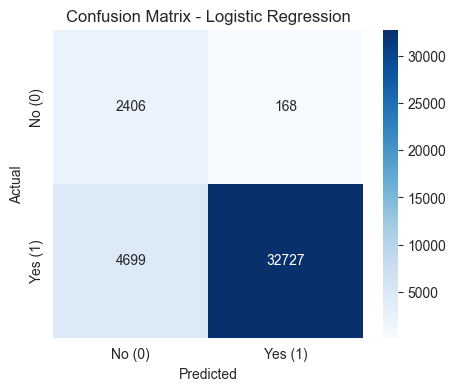

In [37]:
#Evaluation
log_results, log_proba = evaluate_model(log_model,X_train_scaled,y_train,'Logistic Regression')